In [14]:
# Add project root to path so we can import from data_manipulation and model
import sys
from pathlib import Path

def _find_project_root():
    cwd = Path.cwd()
    if (cwd / "data_manipulation").is_dir():
        return cwd
    if (cwd.parent / "data_manipulation").is_dir():
        return cwd.parent
    return cwd  # fallback

project_root = _find_project_root()
if str(project_root) not in sys.path:
    sys.path.insert(0, str(project_root))

In [15]:
import numpy as np
import matplotlib.pyplot as plt
from functools import partial

# Imports from data_manipulation and model
from data_manipulation.data_creation import create_data_all_data, create_data_consolidated_by_store, create_data_consolidated_by_item, create_data_consolidated_by_both
from data_manipulation.data_split import create_dataloader, DemandDataset
from model.functions import pinball_loss, rmse, train, get_test_loss

In [16]:
specs = [
    "7_day_rolling_mean",
    "30_day_rolling_mean",
    "90_day_rolling_mean",
    "180_day_rolling_mean",
    "365_day_rolling_mean",
    "7_day_rolling_volatility",
    "30_day_rolling_volatility",
    "90_day_rolling_volatility",
    "180_day_rolling_volatility",
    "365_day_rolling_volatility",
    "7_day_rolling_min",
    "30_day_rolling_min",
    "90_day_rolling_min",
    "180_day_rolling_min",
    "365_day_rolling_min",
    "7_day_rolling_ema",
    "30_day_rolling_ema",
    "90_day_rolling_ema",
    "180_day_rolling_ema",
    "365_day_rolling_ema",
    "1_day_lag",
    "2_day_lag",
    "3_day_lag",
    "4_day_lag",
    "5_day_lag",
    "6_day_lag",
    "7_day_lag",
    "14_day_lag",
    "28_day_lag",
    "365_day_lag",
    "diff_1_day",
    "diff_7_day",
    "diff_30_day",
    "diff_90_day",
    "diff_180_day",
    "diff_365_day",
]

In [17]:
# Get data for store 1 item 1
df, drop_columns, target_columns = create_data_all_data(
    specs=specs,
    data_mask=[
        ("store", 1),
        ("item", 1)
    ]
    )
X = df.drop(columns=drop_columns)
y = df[target_columns]

In [18]:
print(X.columns)

Index(['7_day_rolling_mean', '30_day_rolling_mean', '90_day_rolling_mean',
       '180_day_rolling_mean', '365_day_rolling_mean',
       '7_day_rolling_volatility', '30_day_rolling_volatility',
       '90_day_rolling_volatility', '180_day_rolling_volatility',
       '365_day_rolling_volatility', '7_day_rolling_min', '30_day_rolling_min',
       '90_day_rolling_min', '180_day_rolling_min', '365_day_rolling_min',
       '7_day_rolling_ema', '30_day_rolling_ema', '90_day_rolling_ema',
       '180_day_rolling_ema', '365_day_rolling_ema', '1_day_lag', '2_day_lag',
       '3_day_lag', '4_day_lag', '5_day_lag', '6_day_lag', '7_day_lag',
       '14_day_lag', '28_day_lag', '365_day_lag', 'diff_1_day', 'diff_7_day',
       'diff_30_day', 'diff_90_day', 'diff_180_day', 'diff_365_day'],
      dtype='str')


In [19]:
corr_matrix = np.corrcoef(X, rowvar=False)
print(corr_matrix)

[[ 1.00000000e+00  9.18836385e-01  7.49195789e-01 ...  3.81573621e-01
   4.36731101e-01  1.85582844e-01]
 [ 9.18836385e-01  1.00000000e+00  8.84111202e-01 ...  2.62512159e-01
   3.71854453e-01  1.43924706e-01]
 [ 7.49195789e-01  8.84111202e-01  1.00000000e+00 ... -7.65687340e-04
   1.64352888e-01  1.44530705e-01]
 ...
 [ 3.81573621e-01  2.62512159e-01 -7.65687340e-04 ...  1.00000000e+00
   5.78685690e-01  3.16000070e-01]
 [ 4.36731101e-01  3.71854453e-01  1.64352888e-01 ...  5.78685690e-01
   1.00000000e+00  2.54388137e-01]
 [ 1.85582844e-01  1.43924706e-01  1.44530705e-01 ...  3.16000070e-01
   2.54388137e-01  1.00000000e+00]]


In [20]:
print(corr_matrix.min(), corr_matrix.max())

-0.5253403460993997 1.0


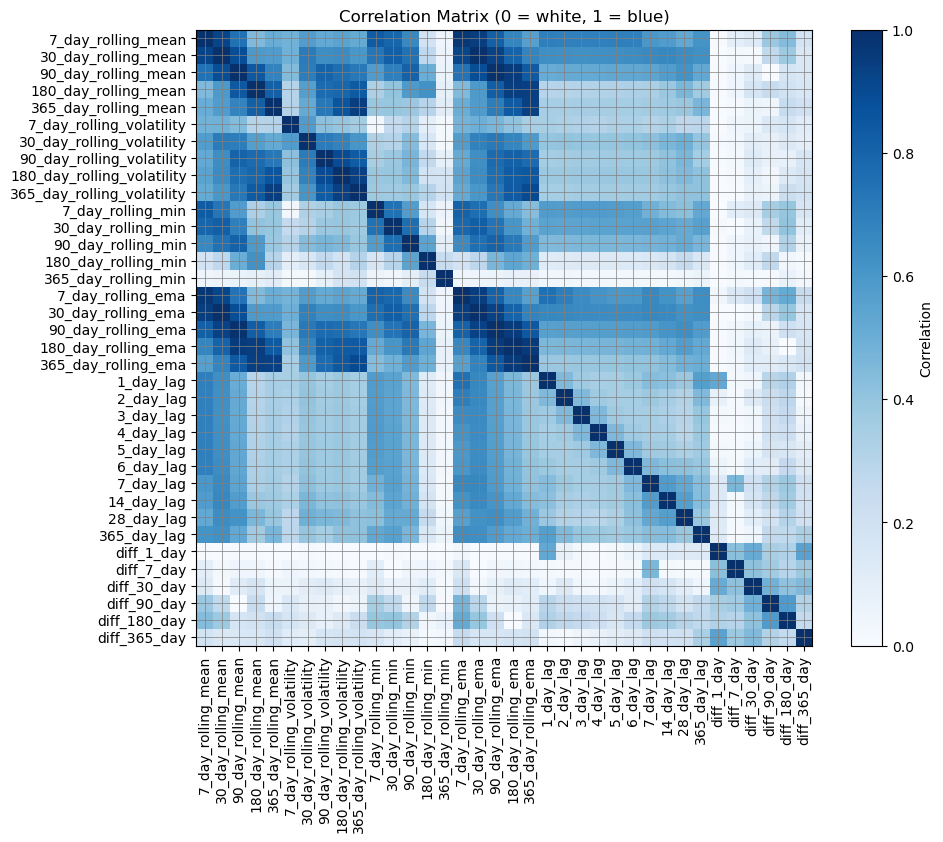

In [21]:
plt.figure(figsize=(10, 8))
plt.imshow(abs(corr_matrix), cmap='Blues', vmin=0, vmax=1)
plt.colorbar(label='Correlation')
plt.title('Correlation Matrix (0 = white, 1 = blue)')
plt.grid(visible=True, color='gray', linewidth=0.5)
plt.xticks(ticks=np.arange(len(specs)), labels=specs, rotation=90)
plt.yticks(ticks=np.arange(len(specs)), labels=specs)
plt.show()

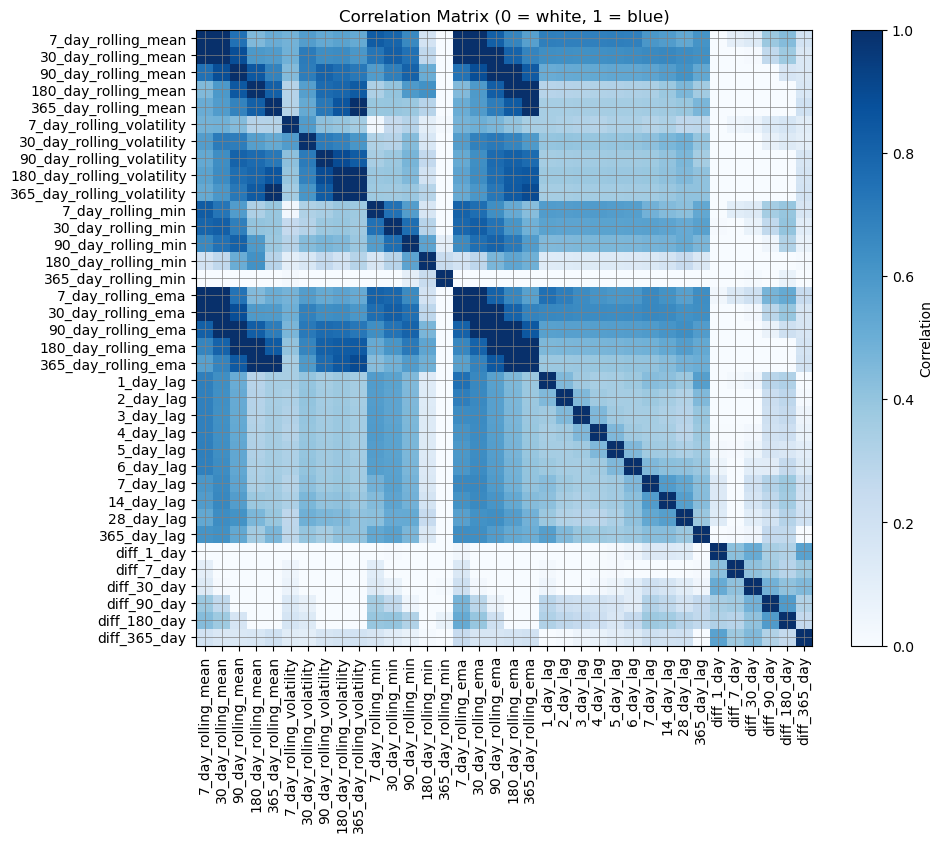

In [25]:
threshold = 0.90
mask = abs(corr_matrix) > threshold
new_corr_matrix = corr_matrix.copy()
new_corr_matrix[mask] = 1
plt.figure(figsize=(10, 8))
plt.imshow(new_corr_matrix, cmap='Blues', vmin=0, vmax=1)
plt.colorbar(label='Correlation')
plt.title('Correlation Matrix (0 = white, 1 = blue)')
plt.grid(visible=True, color='gray', linewidth=0.5)
plt.xticks(ticks=np.arange(len(specs)), labels=specs, rotation=90)
plt.yticks(ticks=np.arange(len(specs)), labels=specs)
plt.show()

In [23]:
# Pearson/Spearman correlations and mutual information (feature x target)
import pandas as pd
from sklearn.feature_selection import mutual_info_regression
from IPython.display import display

# Ensure we use numeric arrays and align rows with valid values
Xv = X.values.astype(float)
y_df = y if isinstance(y, pd.DataFrame) else pd.DataFrame(y)
target_names = list(y_df.columns)
feature_names = list(X.columns)
yV = y_df.values.astype(float)
valid = np.isfinite(Xv).all(axis=1) & np.isfinite(yV).all(axis=1)
Xv = Xv[valid]
yV = yV[valid]

n_features = Xv.shape[1]
n_targets = yV.shape[1]

# Pearson correlations
pearson = np.empty((n_features, n_targets), dtype=float)
for t in range(n_targets):
    yt = yV[:, t]
    for i in range(n_features):
        xt = Xv[:, i]
        pearson[i, t] = np.corrcoef(xt, yt)[0, 1] if np.std(xt) > 0 and np.std(yt) > 0 else np.nan

# Spearman correlations: Pearson correlation on ranks (handles non-linearity)
X_rank = pd.DataFrame(Xv).rank(axis=0).to_numpy()
spearman = np.empty((n_features, n_targets), dtype=float)
for t in range(n_targets):
    yr_rank = pd.Series(yV[:, t]).rank().to_numpy()
    for i in range(n_features):
        xr = X_rank[:, i]
        spearman[i, t] = np.corrcoef(xr, yr_rank)[0, 1] if np.std(xr) > 0 and np.std(yr_rank) > 0 else np.nan

# Mutual information (regression): MI(feature, target) >= 0
mi = np.empty((n_features, n_targets), dtype=float)
for t in range(n_targets):
    mi[:, t] = mutual_info_regression(Xv, yV[:, t], random_state=0)

pearson_df = pd.DataFrame(pearson, index=feature_names, columns=target_names)
spearman_df = pd.DataFrame(spearman, index=feature_names, columns=target_names)
mi_df = pd.DataFrame(mi, index=feature_names, columns=target_names)

# Order Pearson and Spearman and MI by abs of value
pearson_df = pearson_df.abs().sort_values(by=target_names[0], ascending=False)
spearman_df = spearman_df.abs().sort_values(by=target_names[0], ascending=False)
mi_df = mi_df.abs().sort_values(by=target_names[0], ascending=False)

print('Pearson correlation (feature x target):')
display(pearson_df)
print('Spearman correlation (feature x target):')
display(spearman_df)
print('Mutual information (feature x target) - regression:')
display(mi_df)

# Convenience: top MI feature per target
top_mi = mi_df.idxmax(axis=0)
print('Top MI feature per target:')
display(top_mi)

Pearson correlation (feature x target):


,sales
7_day_rolling_ema,0.787933
7_day_rolling_mean,0.687177
30_day_rolling_ema,0.658892
diff_180_day,0.651587
diff_90_day,0.649101
30_day_rolling_mean,0.632604
diff_30_day,0.579039
7_day_rolling_min,0.578469
7_day_lag,0.572769
30_day_rolling_min,0.559807


Spearman correlation (feature x target):


,sales
7_day_rolling_ema,0.784502
7_day_rolling_mean,0.691514
30_day_rolling_ema,0.660653
30_day_rolling_mean,0.634262
diff_90_day,0.631331
diff_180_day,0.612964
7_day_rolling_min,0.588306
7_day_lag,0.571965
30_day_rolling_min,0.563628
diff_30_day,0.557767


Mutual information (feature x target) - regression:


,sales
7_day_rolling_ema,0.502661
diff_180_day,0.482609
7_day_rolling_min,0.447749
diff_90_day,0.324962
7_day_rolling_mean,0.323802
30_day_rolling_ema,0.315901
30_day_rolling_min,0.242267
diff_30_day,0.227001
30_day_rolling_mean,0.223608
7_day_lag,0.217676


Top MI feature per target:


sales    7_day_rolling_ema
dtype: str